<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 25 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Exploratory Data Analysis" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_iris

rng = np.random.default_rng(252)
CYAN="#0891b2"; AMBER="#d97706"; PURPLE="#7c3aed"; GREEN="#059669"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={c: c.replace(" (cm)","").replace(" ","_") for c in iris.frame.columns})
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
print("Ready. iris", df.shape)

Ready. iris (150, 6)


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · FIRST CONTACT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Audit before analysis</div>
<div style="color:#4a5578;margin-top:6px">Run a first-contact audit on the iris frame: report its shape, the dtypes, total missing values, duplicate-row count, and the species balance.</div>
</div>

In [2]:
print("shape:", df.shape)
print("dtypes:\n", df.dtypes.to_string())
print("\ntotal missing:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))
print("species balance:\n", df["species"].value_counts().to_string())

shape: (150, 6)
dtypes:
 sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
target             int64
species         category

total missing: 0
duplicate rows: 1
species balance:
 species
setosa        50
versicolor    50
virginica     50


**Answer:** Iris is **150 rows x 5 columns**, four numeric features plus a categorical `species`, with **no missing values** and (famously) **one duplicate row**. The three species are perfectly **balanced (50 each)**. This audit, shape, dtypes, missingness, duplicates, balance, is the first thing to run on any dataset; it catches problems before you waste effort analyzing them.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · UNIVARIATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Describe one variable</div>
<div style="color:#4a5578;margin-top:6px">For sepal_width, report center (mean, median), spread (SD, IQR), and shape (skew), then draw a histogram. What does the shape tell you?</div>
</div>

mean 3.06, median 3.00
SD 0.44, IQR 0.50
skew +0.32


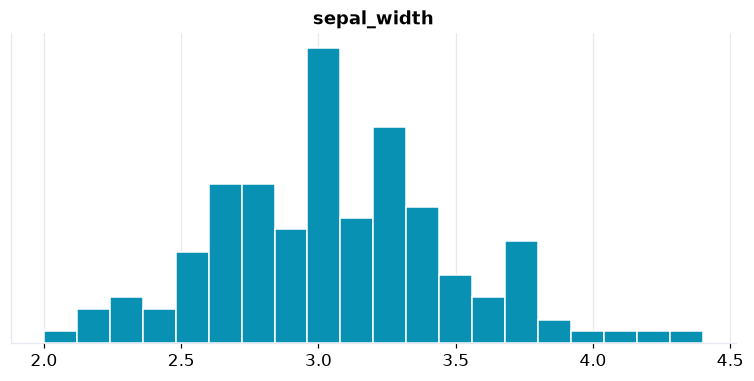

In [3]:
x = df["sepal_width"]
print(f"mean {x.mean():.2f}, median {x.median():.2f}")
print(f"SD {x.std():.2f}, IQR {x.quantile(.75)-x.quantile(.25):.2f}")
print(f"skew {x.skew():+.2f}")
fig, ax = plt.subplots(figsize=(7,3.6))
ax.hist(x, bins=20, color=CYAN, edgecolor="white"); ax.set_title("sepal_width"); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Answer:** `sepal_width` centers near **3.05** (mean ≈ median, so roughly symmetric), with an SD around **0.43** and a small positive **skew** (~+0.3). The histogram is fairly bell-shaped and unimodal, unlike petal length, this feature does not split cleanly by species. Center, spread, and shape together describe a single variable; the chart confirms what the numbers suggest.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · BIVARIATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Compare across groups</div>
<div style="color:#4a5578;margin-top:6px">Is petal_width different across species? Compute the mean petal_width per species and draw side-by-side box plots.</div>
</div>

species
setosa        0.25
versicolor    1.33
virginica     2.03


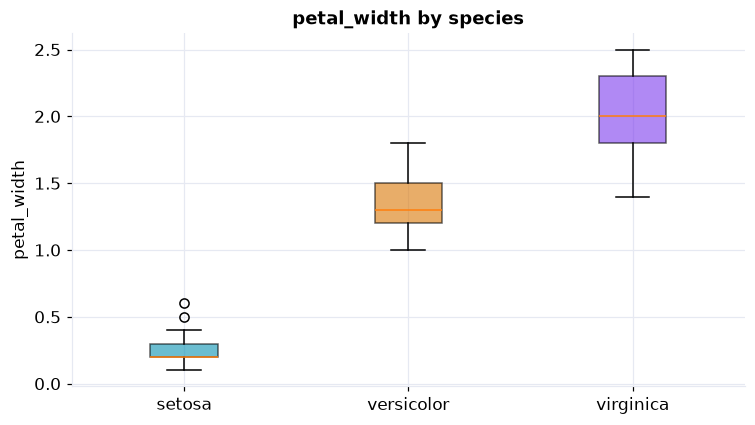

In [4]:
means = df.groupby("species", observed=True)["petal_width"].mean().round(2)
print(means.to_string())
cmap = {"setosa":CYAN, "versicolor":AMBER, "virginica":PURPLE}
groups = [df.loc[df["species"]==s,"petal_width"].values for s in cmap]
fig, ax = plt.subplots(figsize=(7,4))
bp = ax.boxplot(groups, patch_artist=True)
for p,c in zip(bp["boxes"], cmap.values()): p.set_facecolor(c); p.set_alpha(0.6)
ax.set_xticks([1,2,3]); ax.set_xticklabels(list(cmap)); ax.set_ylabel("petal_width"); ax.set_title("petal_width by species")
plt.tight_layout(); plt.show()

**Answer:** Petal width rises sharply across species, roughly **0.25 (setosa) → 1.3 (versicolor) → 2.0 (virginica)**, and the box plots barely overlap. That clean separation makes petal_width a strong predictor of species. Comparing a numeric variable across a categorical one (group means + side-by-side box/violin plots) is the standard categorical-vs-numeric bivariate move.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · CORRELATION MATRIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find the redundant pair</div>
<div style="color:#4a5578;margin-top:6px">Compute the correlation matrix of the four iris features and identify the most strongly correlated pair (a multicollinearity flag).</div>
</div>

In [5]:
feat = ["sepal_length","sepal_width","petal_length","petal_width"]
corr = df[feat].corr()
print(corr.round(2).to_string())
# strongest off-diagonal pair
c = corr.where(~np.eye(4, dtype=bool)).abs()
i, j = np.unravel_index(np.nanargmax(c.values), c.shape)
print(f"\nstrongest pair: {feat[i]} & {feat[j]} (r = {corr.iloc[i,j]:.2f})")

              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00

strongest pair: petal_length & petal_width (r = 0.96)


**Answer:** **petal_length and petal_width** are the most correlated pair (**r ≈ 0.96**), nearly redundant. On a heatmap they would form a hot block, the visual signature of **multicollinearity**. For a linear model you might drop or combine one of them, since two near-identical features add little and can destabilize coefficient estimates (feature selection, Chapter 24).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · LINEAR-ONLY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pearson vs Spearman</div>
<div style="color:#4a5578;margin-top:6px">Create a monotonic but curved relationship (e.g. y = x squared on positive x). Compute Pearson and Spearman correlation. Why do they differ, and what is the lesson?</div>
</div>

Pearson  (linear)    = 0.967
Spearman (monotonic) = 0.996


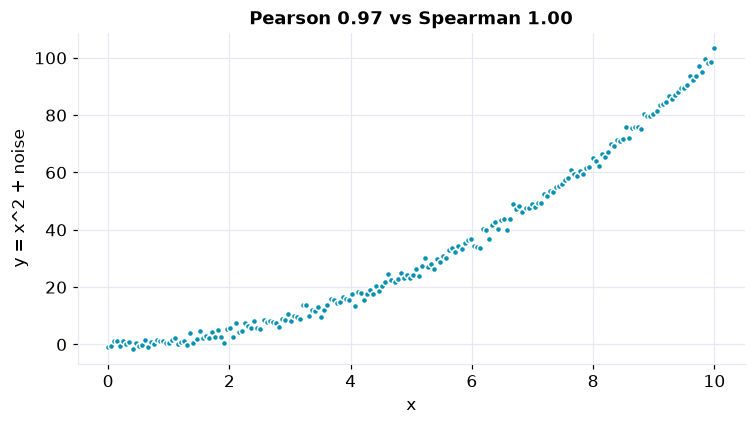

In [6]:
x = np.linspace(0, 10, 200)
y = x**2 + rng.normal(0, 1.5, 200)     # monotonic but curved
pe = stats.pearsonr(x, y)[0]; sp = stats.spearmanr(x, y)[0]
print(f"Pearson  (linear)    = {pe:.3f}")
print(f"Spearman (monotonic) = {sp:.3f}")
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(x, y, color=CYAN, s=16, edgecolor="white"); ax.set_title(f"Pearson {pe:.2f} vs Spearman {sp:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y = x^2 + noise")
plt.tight_layout(); plt.show()

**Answer:** **Spearman is higher than Pearson.** Pearson measures *linear* association, so a curved (but perfectly monotonic) relationship deflates it; Spearman correlates the **ranks**, so it sees that y always rises with x and lands near 1. The lesson: a correlation coefficient, and a correlation heatmap, captures **linear** structure only, so a near-zero Pearson does not mean "unrelated." Always plot the data (the Anscombe lesson from Chapter 15).

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You audited a dataset, described single variables, compared across groups, read a correlation matrix for multicollinearity, and saw why linear correlation can hide a perfect curve. EDA is where understanding happens, and it closes out the data-preparation half of the book.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>